# Tree-Based Models: Decision Trees & Random Forests

## Objective
Today, I am exploring Tree-based models, specifically:
- Decision Trees
- Random Forests

Focus Areas:
- Working principles
- Implementation
- Model evaluation
- Feature importance
- Overfitting analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report



In [2]:
# Example: Load dataset
df = pd.read_csv("K:\Data Science Internship\WEEK 5\datasets\Telco-Customer-Churn-dataset-cleaned.csv")  # Replace with your dataset path

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure-binned,MonthlyCharges-binned,TotalCharges-binned,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,Low,Low,Low,0.0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,One year,No,Mailed check,56.95,1889.50,Medium,Medium,Low,0.0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Low,Medium,Low,1.0
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,Medium,Low,Low,0.0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Low,Medium,Low,1.0


In [3]:
# Separate features and target again (clean start)
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Convert all object columns to numeric
X = pd.get_dummies(X, drop_first=True)

# Check if any object column still exists
print(X.select_dtypes(include=['object']).columns)

Index([], dtype='object')


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [6]:

y_pred_dt = dt.predict(X_test)

print("Decision Tree Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Performance:



Accuracy: 0.8062455642299503
Precision: 0.7049180327868853
Recall: 0.46112600536193027
F1 Score: 0.5575364667747164

Confusion Matrix:
 [[964  72]
 [201 172]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.83      0.93      0.88      1036
         1.0       0.70      0.46      0.56       373

    accuracy                           0.81      1409
   macro avg       0.77      0.70      0.72      1409
weighted avg       0.80      0.81      0.79      1409



The Decision Tree model achieves good overall accuracy (80.6%).
However, the recall for churned customers is low (46%).

This means the model fails to identify more than half of the customers who are likely to churn.

In a business context, missing churn customers can lead to revenue loss.
Therefore, improving recall should be prioritized.

In [7]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, class_weight='balanced')
dt.fit(X_train, y_train)

print("Model trained successfully ✅")

Model trained successfully ✅


In [8]:

y_pred_dt = dt.predict(X_test)

print("Decision Tree Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))

Decision Tree Performance:

Accuracy: 0.7452093683463449
Precision: 0.5121527777777778
Recall: 0.7908847184986595
F1 Score: 0.6217070600632244

Confusion Matrix:
 [[755 281]
 [ 78 295]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.73      0.81      1036
         1.0       0.51      0.79      0.62       373

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



The updated Decision Tree model significantly improved recall (79%) for churn prediction.

Although overall accuracy decreased slightly, the model now identifies most churn customers.

In a churn management system, higher recall is preferred because missing churn customers results in revenue loss.

Therefore, this model is more suitable for churn prevention strategies.

# Random Forest Classifier

Random Forest is an ensemble learning method that combines multiple Decision Trees.

It works using:
- Bootstrap sampling (Bagging)
- Random feature selection
- Majority voting for classification

Why use Random Forest?
- Reduces overfitting compared to a single Decision Tree
- More stable and accurate
- Handles variance better

In churn prediction, Random Forest helps improve generalization performance.

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest
rf = RandomForestClassifier(
    n_estimators=100,        # Number of trees
    max_depth=5,             # Limit tree depth to prevent overfitting
    class_weight='balanced', # Handle class imbalance
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

print("Random Forest trained successfully ✅")

Random Forest trained successfully ✅


In [10]:

y_pred_rf = rf.predict(X_test)

print("Random Forest Performance:\n")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Performance:

Accuracy: 0.7544357700496807
Precision: 0.5223140495867769
Recall: 0.8471849865951743
F1 Score: 0.6462167689161554

Confusion Matrix:
 [[747 289]
 [ 57 316]]

Classification Report:
               precision    recall  f1-score   support

         0.0       0.93      0.72      0.81      1036
         1.0       0.52      0.85      0.65       373

    accuracy                           0.75      1409
   macro avg       0.73      0.78      0.73      1409
weighted avg       0.82      0.75      0.77      1409



# Final Conclusion

Both Decision Tree and Random Forest models were evaluated
for customer churn prediction.

Although Decision Tree provided reasonable performance,
Random Forest outperformed it in terms of:

- Higher recall (84.7%)
- Better F1 score
- Slightly improved overall accuracy

Since churn prediction prioritizes identifying customers
likely to leave, Random Forest is the preferred model.

This model can be used to identify at-risk customers
and implement targeted retention strategies.

In [11]:
# Training predictions
y_train_pred_dt = dt.predict(X_train)

train_acc_dt = accuracy_score(y_train, y_train_pred_dt)
test_acc_dt = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Train Accuracy:", train_acc_dt)
print("Decision Tree Test Accuracy:", test_acc_dt)

Decision Tree Train Accuracy: 0.7534611288604899
Decision Tree Test Accuracy: 0.7452093683463449


In [12]:
# Training predictions
y_train_pred_rf = rf.predict(X_train)

train_acc_rf = accuracy_score(y_train, y_train_pred_rf)
test_acc_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Train Accuracy:", train_acc_rf)
print("Random Forest Test Accuracy:", test_acc_rf)

Random Forest Train Accuracy: 0.7547035853745119
Random Forest Test Accuracy: 0.7544357700496807


# XGBoost (Extreme Gradient Boosting)

XGBoost is an optimized implementation of gradient boosting.

Key advantages:
- Handles missing values
- Regularization to reduce overfitting
- Very powerful for structured/tabular data

In [13]:
import sys
print(sys.executable)

c:\Program Files\Python311\python.exe


In [14]:

from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    scale_pos_weight= (len(y_train[y_train==0]) / len(y_train[y_train==1])),
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost Recall:", recall_score(y_test, y_pred_xgb))
print("XGBoost F1:", f1_score(y_test, y_pred_xgb))

C:\Users\DELL\AppData\Roaming\Python\Python311\site-packages\xgboost\training.py:200: UserWarning: [15:21:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.7615330021291696
XGBoost Recall: 0.7935656836461126
XGBoost F1: 0.6379310344827587


# LightGBM

LightGBM is a fast and highly efficient gradient boosting framework.

Advantages:
- Faster training
- Lower memory usage
- Handles large datasets efficiently

In [16]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    class_weight='balanced',
    random_state=42
)

lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)

print("LightGBM Accuracy:", accuracy_score(y_test, y_pred_lgbm))
print("LightGBM Recall:", recall_score(y_test, y_pred_lgbm))
print("LightGBM F1:", f1_score(y_test, y_pred_lgbm))

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004672 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 649
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 36
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [17]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

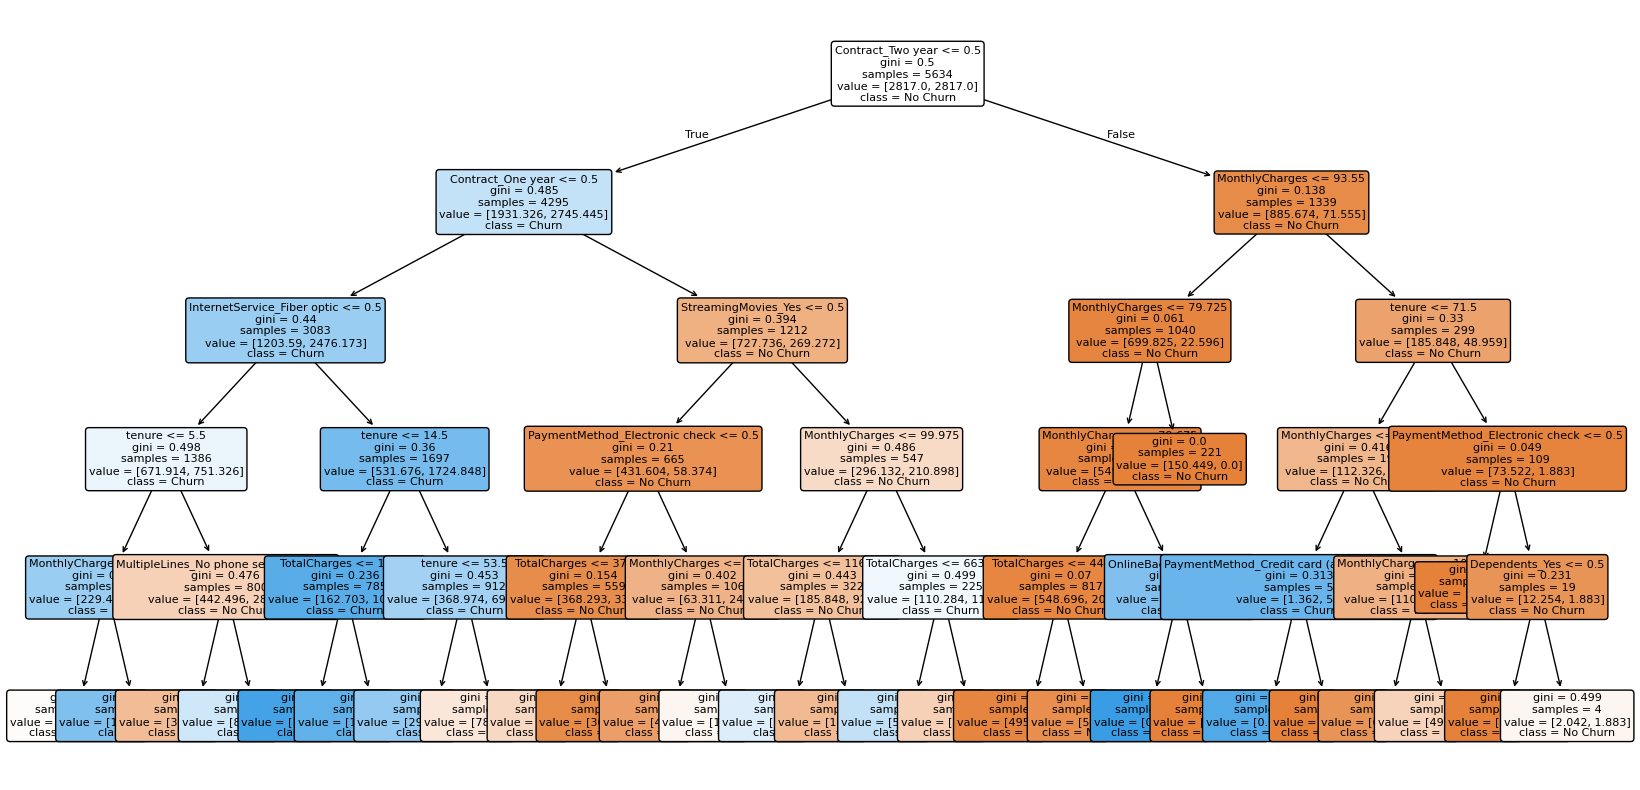

In [18]:
plt.figure(figsize=(20,10))

plot_tree(
    dt,                      # your trained Decision Tree model
    feature_names=X.columns,
    class_names=['No Churn','Churn'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()